# 02 — Conditional experiments

The inverse problem observes $y = Ax + \varepsilon$ with $A = (1\;0)$ and $\sigma = 0.1$, so
only the first coordinate is seen and the posterior $p(x|y)$ is bimodal.

Three methods each learn a Gaussian noise adapter $q_\phi(z|y)$ and differ in what happens to
the flow map. The frozen-θ baseline keeps it fixed. The unconstrained-θ baseline trains it
jointly with no constraint. VFM trains it jointly with the mean-flow constraint.

Shared machinery comes first, copied from `train_vfm.py`, `compute_metrics.py` and
`PlotViz.ipynb`, then one section per method.

## Setup

In [1]:
import itertools
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from torch.func import jvp
from copy import deepcopy
from scipy.stats import gaussian_kde
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

torch.manual_seed(0)
np.random.seed(0)

CKPT_DIR = Path("../checkerboard_example/checkpoints")
OUT_DIR = Path("ckpts"); OUT_DIR.mkdir(exist_ok=True)
FIG_DIR = Path("figures/02"); FIG_DIR.mkdir(parents=True, exist_ok=True)

# Experiment constants (paper Appendix B.1 / PlotViz.ipynb)
sigma = 0.1   # observation noise std
K = 4         # sampling steps for evaluation/plots
J = 100       # posterior samples per observation in plots


device: cuda


## Data and observation model

`sample_y` implements $y = x_1 + \sigma\varepsilon$.

In [2]:
def sample_checkerboard(n_samples, n_squares=4):
    assert n_squares % 2 == 0

    x = np.random.rand(n_samples, 2)
    idx = (x * n_squares).astype(int)
    mask = (idx[:, 0] + idx[:, 1]) % 2 == 0

    while not mask.all():
        n_bad = (~mask).sum()
        x_new = np.random.rand(n_bad, 2)
        idx_new = (x_new * n_squares).astype(int)

        x[~mask] = x_new
        idx[~mask] = idx_new
        mask = (idx[:, 0] + idx[:, 1]) % 2 == 0

    return 4.0 * (x - np.array([[0.5, 0.5]]))


def sample_y(x, sigma_obs):
    # A = [1,0], so observe first coord
    y = x[:, :1] + sigma_obs * torch.randn(x.shape[0], 1, device=x.device, dtype=x.dtype)
    return y


## Models, reparameterisation, KL

`Adapter` is a SiLU MLP taking the scalar $y$ and emitting $\mu_\phi(y)$ and
$\log\sigma_\phi(y)$, with the log-std clamped to $[-6, 3]$.

`reparam_sample` draws $z = \mu + e^{\log\sigma}\odot\varepsilon$, J samples per observation.
`kl` is the closed-form KL to $\mathcal{N}(0,I)$, one value per sample.

In [3]:
class MeanFlowMLP(nn.Module):
    """
    u_theta(z, r, t) -> R^2
    Inputs: z in R^2, (t, r) scalars (two extra channels)
    """
    def __init__(self, hidden=256, depth=4):
        super().__init__()
        layers = []
        in_dim = 2 + 2  # z + (t, r)
        dim = in_dim
        for _ in range(depth):
            layers += [nn.Linear(dim, hidden), nn.SiLU()]
            dim = hidden
        layers += [nn.Linear(dim, 2)]
        self.net = nn.Sequential(*layers)

    def forward(self, z, r, t):
        inp = torch.cat([z, t, r], dim=1)
        return self.net(inp)


class Adapter(nn.Module):
    def __init__(self, hidden=128, depth=3, z_dim=2):
        super().__init__()
        layers = []
        in_dim = 1  # y is scalar
        dim = in_dim
        for _ in range(depth):
            layers += [nn.Linear(dim, hidden), nn.SiLU()]
            dim = hidden
        self.backbone = nn.Sequential(*layers)
        self.mu = nn.Linear(dim, z_dim)
        self.log_std = nn.Linear(dim, z_dim)  # log sigma

    def forward(self, y):
        h = self.backbone(y)
        mu = self.mu(h)
        log_std = self.log_std(h).clamp(-6.0, 3.0)  # stability
        return mu, log_std


def reparam_sample(mu, log_std, J=None):
    # mu, log_std: Shape (B, D)
    if J is None:
        eps = torch.randn_like(mu)
        z = mu + torch.exp(log_std) * eps
    else:
        # Get samples of shape (B, J, D)
        B, D = mu.shape
        eps = torch.randn(B, J, D, device=mu.device, dtype=mu.dtype)
        z = mu.unsqueeze(1) + torch.exp(log_std).unsqueeze(1) * eps
    return z


def kl(mu, log_std):
    return 0.5 * torch.sum(torch.exp(2*log_std) + mu**2 - 1.0 - 2*log_std, dim=1)


## Samplers and training utilities

`f_theta` here is the training version, without `@torch.no_grad()`, because the observation loss
needs gradients through it. `sample_t_r` draws the time pairs for the mean-flow loss, setting
r=t for a fixed fraction of them. `update_ema` copies model weights into a frozen copy.

In [4]:
def sample_t_r(batch_size, device, ratio_r_neq_t=0.25):
    """
    Sample t,r in [0,1] with t>=r by swapping.
    Optionally set r=t for a fraction (1-ratio) of samples.
    """
    t = torch.rand(batch_size, 1, device=device)
    r = torch.rand(batch_size, 1, device=device)
    t, r = torch.maximum(t, r), torch.minimum(t, r)

    if ratio_r_neq_t < 1.0:
        keep = (torch.rand(batch_size, 1, device=device) < ratio_r_neq_t)
        r = torch.where(keep, r, t)
    return t, r


def f_theta(z, u_model, K=1):
    # z has shape (B,D) or (B,J,D)
    if z.ndim == 3:
        B, J, D = z.shape
        z = z.reshape(B * J, D)
    ts = torch.linspace(0.0, 1.0, K + 1, device=z.device)
    for i in range(K, 0, -1):
        t_i = torch.full((z.shape[0], 1), ts[i].item(), device=z.device)
        r_i = torch.full((z.shape[0], 1), ts[i-1].item(), device=z.device)
        z = z - (t_i - r_i) * u_model(z, r_i, t_i)
    if 'J' in locals():
        z = z.reshape(B, J, D)
    return z


@torch.no_grad()
def update_ema(ema_model, model, decay=0.9999):
    """Exponential moving average update (train_vfm.py, simplified: no DDP prefixes,
    no buffers -- MeanFlowMLP has only plain parameters)."""
    ema_params = dict(ema_model.named_parameters())
    for name, p_model in model.named_parameters():
        p_ema = ema_params[name]
        p_ema.mul_(decay).add_(p_model.data, alpha=1.0 - decay)


## Load pretrained checkpoints


In [5]:
def load_model(path):
    model = MeanFlowMLP(hidden=512, depth=6).to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model

fm_model = load_model(CKPT_DIR / "fm_model.pt")
mf_model = load_model(CKPT_DIR / "mf_model.pt")


## Ground-truth posterior by rejection sampling

Propose from the checkerboard prior and accept with probability
$\exp(-(y - x_1)^2 / 2\sigma^2)$, repeating until J samples per observation are collected. This
gives exact posterior samples to compare each method against.

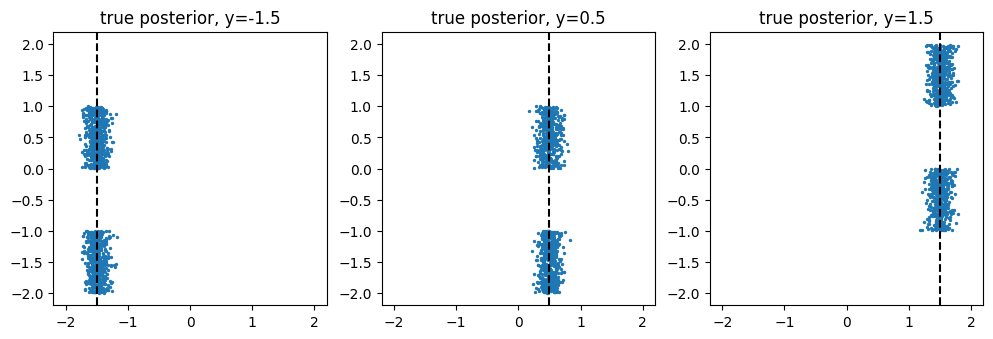

In [6]:
@torch.no_grad()
def sample_posterior_rejection(
    y,                       # (B,1) or (B,)
    sigma_obs: float,
    J: int,
    prior_sampler,           # callable: prior_sampler(n) -> (n,2) numpy
    proposal_K: int = 4096,  # proposals per batch item per iteration
    max_rounds: int = 10_000,
    device=None,
):
    if device is None:
        device = y.device
    if y.ndim == 1:
        y = y[:, None]
    y = y.to(device)

    B = y.shape[0]
    out = torch.empty(B, J, 2, device=device)
    filled = torch.zeros(B, dtype=torch.long, device=device)

    sigma_t = torch.tensor(sigma_obs, device=device, dtype=y.dtype)

    for _ in range(max_rounds):
        done = filled >= J
        if bool(done.all()):
            break

        # Propose B * proposal_K samples from the prior
        x_prop = prior_sampler(B * proposal_K).reshape(B, proposal_K, 2)
        x_prop = torch.tensor(x_prop, device=device, dtype=torch.float32)

        # Acceptance prob: exp(-(y - x1)^2 / (2 sigma^2))
        diff = (y[:, 0:1] - x_prop[:, :, 0]) / sigma_t
        accept_prob = torch.exp(-0.5 * diff**2)  # (B, proposal_K)

        u = torch.rand(B, proposal_K, device=device, dtype=accept_prob.dtype)
        accept = u < accept_prob  # (B, proposal_K)

        for b in range(B):
            if filled[b] >= J:
                continue
            xb_acc = x_prop[b][accept[b]]  # (n_acc,2)
            if xb_acc.numel() == 0:
                continue
            need = J - int(filled[b].item())
            take = min(need, xb_acc.shape[0])
            out[b, filled[b]:filled[b] + take] = xb_acc[:take]
            filled[b] += take

    if not bool((filled >= J).all()):
        raise RuntimeError(
            f"Rejection sampler did not finish: filled min={int(filled.min())}/{J}. "
            f"Try increasing proposal_K or sigma_obs."
        )

    return out


# Demo: the true posterior is bimodal
y_demo = torch.tensor([-1.5, 0.5, 1.5], device=device)
x_post = sample_posterior_rejection(y_demo, sigma, J=1000,
                                    prior_sampler=sample_checkerboard).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, yv, xp in zip(axes, y_demo.cpu().numpy(), x_post):
    ax.scatter(xp[:, 0], xp[:, 1], s=2)
    ax.vlines(yv, -2.2, 2.2, linestyles="dashed", colors="black")
    ax.set_title(f"true posterior, y={yv:.1f}")
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2); ax.set_aspect("equal")
plt.savefig(FIG_DIR / "true_posterior_demo.png", dpi=120, bbox_inches="tight")
plt.show()


## Plotting helpers

Copied from `PlotViz.ipynb`. `plot_noise_and_data` renders one method as two panels. The noise
panel shows 10k unconditional latents coloured by the checkerboard cell their decoded sample
lands in, with KDE contours of $q_\phi(z|y)$ on top. The data panel shows the decoded samples
with the same colours, the observation line and the true cell boundaries.

The original signature had a typo, `adpater`, and silently used the global `adapter`. Here the
parameter is used.

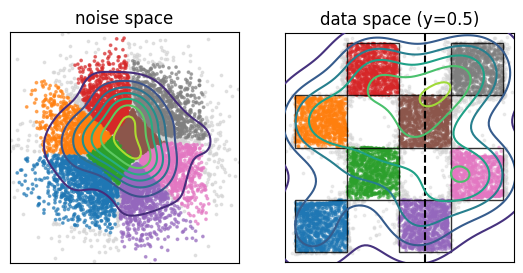

In [7]:
def compute_kde(data):
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    data = data[:, :2].T  # (2, N) for gaussian_kde
    return gaussian_kde(data)


def get_kde_points(data):
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    xmin, ymin = data.min(axis=0)
    xmax, ymax = data.max(axis=0)
    dx, dy = xmax - xmin, ymax - ymin
    xmin -= 0.2 * dx; xmax += 0.2 * dx
    ymin -= 0.2 * dy; ymax += 0.2 * dy

    xx, yy = np.meshgrid(np.linspace(xmin, xmax, 100),
                         np.linspace(ymin, ymax, 100))
    pts = np.vstack([xx.ravel(), yy.ravel()])
    return pts, (xmin, xmax, ymin, ymax)


def unscale_to_unit(x_scaled):
    return x_scaled / 4.0 + 0.5


def checkerboard_block_id(x01, n_squares=4, filled_parity=0):
    """
    x01: (N,2) points assumed in [0,1]^2
    returns block_id: (N,) long, -1 if outside [0,1]^2 or not a filled square
    """
    x = x01
    inside = (x[:,0] >= 0) & (x[:,0] < 1) & (x[:,1] >= 0) & (x[:,1] < 1)

    ij = torch.floor(x * n_squares).long().clamp(0, n_squares-1)
    i, j = ij[:,0], ij[:,1]

    filled = ((i + j) % 2 == filled_parity)

    ok = inside & filled
    block_id = torch.full((x.shape[0],), -1, dtype=torch.long, device=x.device)
    block_id[ok] = i[ok] * n_squares + j[ok]  # unique id per grid cell
    return block_id


@torch.no_grad()
def meanflow_k_steps_with_latents(model, n_samples=10_000, K=10, device="cpu"):
    model.eval()
    z = torch.randn(n_samples, 2, device=device)
    z1 = z.clone()
    x0 = f_theta(z, model, K=K)
    return z1, x0


def plot_noise_and_data(model, adapter, y_val, K=K, J=J):
    with torch.no_grad():
        y0 = torch.tensor([[y_val]], device=device, dtype=torch.float32)
        mu, log_std = adapter(y0.repeat(J, 1))  # (J, 2)
        z = reparam_sample(mu, log_std)         # (J, 2)
        x_samp = f_theta(z, model, K).cpu()     # (J, 2)

    z_np = z.detach().cpu().numpy()

    kde_z = compute_kde(z_np)
    z_pts, z_range = get_kde_points(z_np)
    kde_x = compute_kde(x_samp)
    x_pts, x_range = get_kde_points(x_samp)

    dens_z = np.asarray(kde_z(z_pts)).reshape(100, 100)
    dens_x = np.asarray(kde_x(x_pts)).reshape(100, 100)

    # unconditional latents/samples, colored by landing cell
    z1, x0 = meanflow_k_steps_with_latents(model, n_samples=10_000, K=K, device=device)

    x01 = unscale_to_unit(x0)  # map to [0,1]^2 for block assignment
    block_id = checkerboard_block_id(x01, n_squares=4, filled_parity=0)
    valid_t = block_id >= 0
    unique_blocks = torch.unique(block_id[valid_t]).tolist()
    block_to_compact = {b: k for k, b in enumerate(unique_blocks)}
    labels = torch.full_like(block_id, -1)
    for b, k in block_to_compact.items():
        labels[block_id == b] = k

    z1_np = z1.cpu().numpy()
    x0_np = x0.cpu().numpy()
    lab_np = labels.cpu().numpy()

    valid = lab_np >= 0
    invalid = ~valid
    cmap = plt.get_cmap("tab10")
    colors = cmap(lab_np[valid] % cmap.N)

    fig, (ax_z, ax_x) = plt.subplots(1, 2, figsize=(6.5, 3))

    # noise space
    ax_z.scatter(z1_np[invalid, 0], z1_np[invalid, 1], s=3, alpha=0.6, c="lightgrey", rasterized=True)
    ax_z.scatter(z1_np[valid, 0], z1_np[valid, 1], s=3, alpha=0.6, c=colors, rasterized=True)
    ax_z.contour(dens_z, origin='lower', extent=z_range, zorder=100)
    ax_z.set_xlim(-3.2, 3.2); ax_z.set_ylim(-3.2, 3.2)
    ax_z.set_xticks([]); ax_z.set_yticks([])
    ax_z.set_title("noise space")

    # data space
    ax_x.scatter(x0_np[invalid, 0], x0_np[invalid, 1], s=3, alpha=0.4, c="lightgrey", rasterized=True)
    ax_x.scatter(x0_np[valid, 0], x0_np[valid, 1], s=3, alpha=0.4, c=colors, rasterized=True)
    ax_x.contour(dens_x, origin='lower', extent=x_range, zorder=100)
    ax_x.vlines(y_val, -2.2, 2.2, linestyles="dashed", colors="black")
    ax_x.set_xlim(-2.2, 2.2); ax_x.set_ylim(-2.2, 2.2)
    squares = [(-2,-2), (-2, 0),
               (-1, 1), (-1,-1),
               ( 0, 0), ( 0,-2),
               ( 1, 1), ( 1,-1)]
    for (sx, sy) in squares:
        ax_x.add_patch(Rectangle((sx, sy), 1, 1, fill=False, edgecolor="k",
                                 linewidth=1, zorder=10, alpha=0.8))
    ax_x.set_aspect("equal", adjustable="box")
    ax_x.set_xticks([]); ax_x.set_yticks([])
    ax_x.set_title(f"data space (y={y_val})")

    return fig


# Machinery check: untrained adapter on the frozen mf_model.
# Colored cells / grey off-manifold points should render; the KDE contours
# (an untrained q(z|y), roughly a unit blob at the origin) will be meaningless.
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)
fig = plot_noise_and_data(mf_model, adapter, y_val=0.5)
fig.savefig(FIG_DIR / "skeleton_check_untrained_adapter.png", dpi=120, bbox_inches="tight")
plt.show()


## Method 1: frozen-θ baseline

Only the adapter is trained. The generator is a frozen copy of `mf_model`.

$$L(\phi) = \mathbb{E}\Big[\tfrac{1}{2\sigma^2}\,(y - A f_\theta(z))^2\Big]
+ \mathrm{KL}(q_\phi(z|y)\,\|\,\mathcal{N}(0,I)), \qquad z \sim q_\phi(z|y).$$

Training decodes at K=1 and the plots evaluate at K=4. 20,000 steps, batch 2048, AdamW learning
rate 2e-4, weight decay 1e-4.

A Gaussian $q_\phi$ cannot cover the two disconnected preimage regions of the bimodal posterior
in a fixed noise partition, so it captures one mode or smears between them.

In [8]:
from torch.utils.data import TensorDataset, DataLoader
import wandb

x_train = torch.tensor(sample_checkerboard(20_000), dtype=torch.float32)
loader = DataLoader(TensorDataset(x_train), batch_size=2048, shuffle=True)

mf_frozen = MeanFlowMLP(hidden=512, depth=6).to(device)
mf_frozen.load_state_dict(mf_model.state_dict())
mf_frozen.eval()
for p in mf_frozen.parameters():
    p.requires_grad_(False)

adapter_frozen = Adapter(hidden=256, depth=4, z_dim=2).to(device)
opt_frozen = torch.optim.AdamW(adapter_frozen.parameters(), lr=2e-4, weight_decay=1e-4)


In [9]:
def train_adapter(adapter, generator, opt, loader, steps=20_000, log_every=1000,
                  beta_kl=1.0, K=1, run_name=None):
    """Adapter(-and-optionally-generator) training with the VAE objective
    (Colab cells 29/34). Whether the generator trains is decided by the caller:
    its parameters' requires_grad flags and membership in `opt`."""
    if run_name is not None:
        wandb.init(project="vfm-checkerboard", name=run_name,
                   config=dict(steps=steps, beta_kl=beta_kl, K_train=K, sigma=sigma,
                               lr=2e-4, weight_decay=1e-4,
                               batch_size=loader.batch_size))
    adapter.train()
    i = 0
    obs_losses, kl_losses, losses = [], [], []

    data_iter = iter(loader)
    while i < steps:
        try:
            (xb,) = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            (xb,) = next(data_iter)

        xb = xb.to(device)

        # sample observation
        y = sample_y(xb, sigma)  # (B,1)

        # q(z|y)
        mu, log_std = adapter(y)
        z = reparam_sample(mu, log_std)

        # predicted observation from the generator
        xhat = f_theta(z, generator, K)     # (B,2)
        yhat = xhat[:, :1]                  # A xhat

        # reconstruction term (Gaussian likelihood)
        obs_loss = 0.5 / (sigma**2) * (y - yhat).pow(2).sum(dim=1)  # (B,)

        # KL term
        kl_loss = kl(mu, log_std)           # (B,)

        loss = (obs_loss + beta_kl * kl_loss).mean()

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        obs_losses.append(obs_loss.mean().item())
        kl_losses.append(kl_loss.mean().item())
        losses.append(loss.item())
        if run_name is not None:
            wandb.log({"loss": losses[-1], "obs_loss": obs_losses[-1],
                       "kl_loss": kl_losses[-1]}, step=i)
        i += 1
        if i % log_every == 0:
            print(f"iter {i:6d}/{steps} | loss {np.mean(losses[-log_every:]):.4f} | "
                  f"obs {np.mean(obs_losses[-log_every:]):.4f} | "
                  f"kl {np.mean(kl_losses[-log_every:]):.4f}")

    if run_name is not None:
        wandb.finish()
    return losses, obs_losses, kl_losses


In [10]:
# ~2 min on the A5000. Needs `wandb login` (or set run_name=None to skip wandb).
losses_f, obs_f, kl_f = train_adapter(adapter_frozen, mf_frozen, opt_frozen, loader,
                                      steps=20_000, run_name="frozen-theta")


iter   1000/20000 | loss 6.4084 | obs 3.8514 | kl 2.5570
iter   2000/20000 | loss 3.9681 | obs 1.3544 | kl 2.6137
iter   3000/20000 | loss 3.9044 | obs 1.2604 | kl 2.6440
iter   4000/20000 | loss 3.8512 | obs 1.1647 | kl 2.6865
iter   5000/20000 | loss 3.8393 | obs 1.1524 | kl 2.6868
iter   6000/20000 | loss 3.8309 | obs 1.1408 | kl 2.6900
iter   7000/20000 | loss 3.8274 | obs 1.1298 | kl 2.6976
iter   8000/20000 | loss 3.8203 | obs 1.1313 | kl 2.6890
iter   9000/20000 | loss 3.8134 | obs 1.1331 | kl 2.6803
iter  10000/20000 | loss 3.8113 | obs 1.1329 | kl 2.6784
iter  11000/20000 | loss 3.8073 | obs 1.1215 | kl 2.6858
iter  12000/20000 | loss 3.8025 | obs 1.1204 | kl 2.6821
iter  13000/20000 | loss 3.7992 | obs 1.1119 | kl 2.6874
iter  14000/20000 | loss 3.7990 | obs 1.1107 | kl 2.6883
iter  15000/20000 | loss 3.7962 | obs 1.1056 | kl 2.6906
iter  16000/20000 | loss 3.7933 | obs 1.1014 | kl 2.6919
iter  17000/20000 | loss 3.7918 | obs 1.1040 | kl 2.6878
iter  18000/20000 | loss 3.7889

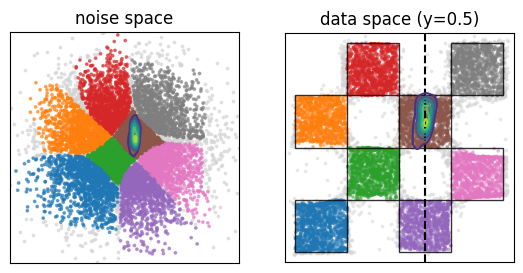

In [11]:
torch.save({"adapter": adapter_frozen.state_dict()}, OUT_DIR / "adapter_only_model.pt")

adapter_frozen.eval()
fig = plot_noise_and_data(mf_frozen, adapter_frozen, y_val=0.5)
fig.savefig(FIG_DIR / "frozen_theta_y0.5.png", dpi=120, bbox_inches="tight")
plt.show()


## Method 2: unconstrained-θ baseline

The same objective and training function as the frozen-θ baseline. The only change is that the
generator starts from the same pretrained weights but stays trainable, and one optimiser updates
$\theta$ and $\phi$ together. Nothing keeps $\theta$ a valid flow map.

The extra freedom lets the model cover both posterior modes, but $\theta$ drifts and many
samples land off the checkerboard.

In [12]:
mf_uncon = MeanFlowMLP(hidden=512, depth=6).to(device)
mf_uncon.load_state_dict(mf_model.state_dict())

adapter_uncon = Adapter(hidden=256, depth=4, z_dim=2).to(device)

opt_uncon = torch.optim.AdamW(
    itertools.chain(
        adapter_uncon.parameters(),
        mf_uncon.parameters(),
    ),
    lr=2e-4,
    weight_decay=1e-4,
)


In [ ]:
# ~3 min on the A5000 (backward pass now also covers the generator).
losses_u, obs_u, kl_u = train_adapter(adapter_uncon, mf_uncon, opt_uncon, loader,
                                      steps=20_000, run_name="unconstrained-theta")

iter   1000/20000 | loss 5.0315 | obs 2.6585 | kl 2.3730
iter   2000/20000 | loss 2.8427 | obs 0.5052 | kl 2.3374
iter   3000/20000 | loss 2.8381 | obs 0.5020 | kl 2.3360
iter   4000/20000 | loss 2.8348 | obs 0.4982 | kl 2.3366
iter   5000/20000 | loss 2.8359 | obs 0.4979 | kl 2.3380
iter   6000/20000 | loss 2.8363 | obs 0.4971 | kl 2.3391
iter   7000/20000 | loss 2.8356 | obs 0.4968 | kl 2.3388
iter   8000/20000 | loss 2.8360 | obs 0.4967 | kl 2.3393
iter   9000/20000 | loss 2.8342 | obs 0.4961 | kl 2.3381
iter  10000/20000 | loss 2.8345 | obs 0.4962 | kl 2.3383
iter  11000/20000 | loss 2.8364 | obs 0.4960 | kl 2.3404
iter  12000/20000 | loss 2.8344 | obs 0.4955 | kl 2.3388
iter  13000/20000 | loss 2.8352 | obs 0.4955 | kl 2.3397
iter  14000/20000 | loss 2.8343 | obs 0.4949 | kl 2.3395
iter  15000/20000 | loss 2.8343 | obs 0.4952 | kl 2.3391
iter  16000/20000 | loss 2.8339 | obs 0.4944 | kl 2.3395
iter  17000/20000 | loss 2.8343 | obs 0.4947 | kl 2.3396
iter  18000/20000 | loss 2.8339

NameError: name 's' is not defined

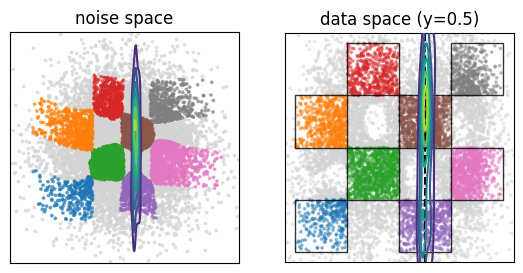

In [14]:
torch.save({"adapter": adapter_uncon.state_dict(),
            "mf_model": mf_uncon.state_dict()},
           OUT_DIR / "joint_adapter_mf_model_naive.pt")

adapter_uncon.eval()
fig = plot_noise_and_data(mf_uncon, adapter_uncon, y_val=0.5)
fig.savefig(FIG_DIR / "unconstrained_theta_y0.5.png", dpi=120, bbox_inches="tight")
plt.show()


## Method 3: VFM

The loss adds the mean-flow term to the two terms above.

$$L = \tfrac{1}{2\tau^2} L_{MF}(\theta;\phi) + \tfrac{1}{2\sigma^2} L_{obs}(\theta^-, \phi)
+ L_{KL}(\phi)$$

The first term keeps $\theta$ a valid flow map, the second hits the observation, and the third
stays near the prior.

There are three differences from the naive baseline. $L_{obs}$ decodes through a stop-gradient
copy $\theta^-$, so it trains only the adapter. $L_{MF}$ trains $\theta$ through the MeanFlow
objective, on interpolants whose noise endpoint comes from the adapter with probability α. The
loss is rescaled by $w = 1/(L+c)$, detached.

### Reproduction note

The released `train_vfm.py` does not reproduce the paper's result at its stated settings. Joint
training degrades the flow map rather than improving it, and its samples stop landing on the
checkerboard. Two separate defects cause this.

First, the mean-flow loss is divided by the interval length, as
`F.mse_loss(u, u_tgt.detach()) / (t - r + 1e-6)`. Three quarters of the sampled time pairs have
r=t, where that divisor falls back to 1e-6 and inflates the term by a factor of about 7.5e5. The
authors' own Colab uses the plain `F.mse_loss(u, u_tgt.detach())`.

Second, the stop-gradient copy of the flow map is a hard copy rather than an exponential moving
average, because `update_ema` is called with `decay=0.0`. At α=1 this makes training oscillate
and then diverge. Setting the decay to 0.999, the rate μ in the paper's Algorithm 2, makes it
stable.

Both fixes are needed. With both, the paper's settings work, although support accuracy recovers
slowly at τ=100 because the mean-flow term then carries a weight of only 5e-5. The Colab's τ=1.0
converges much faster. Checkpoints for both are in `ckpts/`.

In [ ]:
import math

def nlpd(y, x_samples, sigma_obs):
    """
    Negative log predictive density (NLPD)
    y: (B, 1); x_samples: (B, J, D)  ->  (B,)
    """
    B, J_, D = x_samples.shape
    Ax = x_samples[..., 0]           # (B, J)
    y0 = y.squeeze(-1).unsqueeze(1)  # (B, 1)
    log_norm = -0.5 * math.log(2 * math.pi * (sigma_obs ** 2))
    log_probs = log_norm - 0.5 * (y0 - Ax) ** 2 / (sigma_obs ** 2)   # (B, J)
    log_py = torch.logsumexp(log_probs, dim=1) - math.log(J_)
    return -log_py


def crps(x_true, x_samples):
    """
    x_true: (B, D); x_samples: (B, J, D)  ->  (B,)
    """
    B, J_, D = x_samples.shape
    x_true_exp = x_true.unsqueeze(1).expand(B, J_, D)  # (B, J, D)
    term1 = torch.mean(torch.norm(x_samples - x_true_exp, dim=2), dim=1)  # (B,)
    x1 = x_samples.unsqueeze(2)  # (B, J, 1, D)
    x2 = x_samples.unsqueeze(1)  # (B, 1, J, D)
    pairwise_dists = torch.norm(x1 - x2, dim=3)  # (B, J, J)
    term2 = 0.5 * torch.mean(pairwise_dists, dim=(1, 2))  # (B,)
    return term1 - term2  # (B,)


In [ ]:
# VFM hyperparameters (see the reproduction note above)
tau = 100.0                # paper setting; works with the two fixes above. tau=1.0 converges faster
alpha = 1.0                # paper Fig. 10 best; requires the true EMA below
ema_decay = 0.999          # rate mu in Algorithm 2; script's 0.0 diverges at alpha=1
use_ema = True
no_kl = False
ratio_r_neq_t = 0.25
p_adapt, c_adapt = 1.0, 0.01
num_iter = 50_000           # paper Appendix B.1.1; closes the prior-MMD gap vs 20k (see metrics below)

x_val = torch.tensor(sample_checkerboard(1000), dtype=torch.float32).to(device)
J_val = 100

model_vfm = MeanFlowMLP(hidden=512, depth=6).to(device)
model_vfm.load_state_dict(fm_model.state_dict())   # both Colab and script init from the FM model
ema_vfm = deepcopy(model_vfm).to(device)
for p in ema_vfm.parameters():
    p.requires_grad_(False)

adapter_vfm = Adapter(hidden=256, depth=4, z_dim=2).to(device)
opt_vfm = torch.optim.AdamW(itertools.chain(
                                adapter_vfm.parameters(),
                                model_vfm.parameters(),
                            ),
                            lr=2e-4, weight_decay=1e-4)


In [ ]:
def train_vfm(adapter, model, ema, opt, loader, num_iter, log_every=1000, run_name=None):
    if run_name is not None:
        wandb.init(project="vfm-checkerboard", name=run_name,
                   config=dict(tau=tau, alpha=alpha, ema=use_ema, no_kl=no_kl,
                               num_iter=num_iter, ratio_r_neq_t=ratio_r_neq_t,
                               p=p_adapt, c=c_adapt, sigma=sigma,
                               lr=2e-4, weight_decay=1e-4,
                               batch_size=loader.batch_size))
    adapter.train()
    model.train()
    ema.eval()
    i = 0
    obs_losses, kl_losses, mf_losses, losses = [], [], [], []
    data_iter = iter(loader)
    while i < num_iter:
        try:
            (xb,) = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            (xb,) = next(data_iter)

        xb = xb.to(device)
        B = xb.shape[0]

        # sample observation
        y = sample_y(xb, sigma)  # (B,1)

        # q(z|y)
        mu, log_std = adapter(y)
        z = reparam_sample(mu, log_std)

        # observation loss through the stop-grad copy of the flow map
        if use_ema:
            xhat = f_theta(z, ema, 1)          # (B,2)
        else:
            xhat = f_theta(z, model, 1)
        yhat = xhat[:, :1]                     # A xhat

        obs_loss = (0.5 / (sigma**2)) * (y - yhat).pow(2).sum(dim=1)  # (B,)

        # KL term
        kl_loss = kl(mu, log_std)              # (B,)
        if no_kl:
            kl_loss = torch.zeros_like(kl_loss)

        # mean flow loss
        t, r = sample_t_r(B, device=device, ratio_r_neq_t=ratio_r_neq_t)
        mask = (torch.rand(B, 1, device=device) < alpha).float()
        eps = torch.randn_like(xb)
        z = mask * z + (1-mask) * eps
        xt = (1.0 - t) * xb + t * z
        vt = z - xb
        (u, dudt) = jvp(
            model,
            (xt, r, t),
            (vt, torch.zeros_like(r), torch.ones_like(t))
        )
        u_tgt = vt - (t - r) * dudt
        mf_loss_unweighted = F.mse_loss(u, u_tgt.detach())  # released script divides by (t-r+1e-6): collapses; see note
        mf_loss = (0.5 / (tau**2)) * mf_loss_unweighted

        # Adaptive loss
        loss = (mf_loss + obs_loss + kl_loss).mean()
        w = 1 / (loss + c_adapt)**p_adapt
        loss = w.detach() * loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        update_ema(ema, model, decay=ema_decay)  # true EMA; script's decay=0.0 diverges at alpha=1

        obs_losses.append(obs_loss.mean().item())
        kl_losses.append(kl_loss.mean().item())
        mf_losses.append(mf_loss_unweighted.mean().item())
        losses.append(loss.item())
        if run_name is not None:
            wandb.log({"total_loss": losses[-1], "obs_loss": obs_losses[-1],
                       "kl_loss": kl_losses[-1], "mf_loss": mf_losses[-1]}, step=i)
        i += 1
        if i % log_every == 0:
            print(f"iter {i:6d}/{num_iter} | loss {np.mean(losses[-log_every:]):.4f} | "
                  f"obs {np.mean(obs_losses[-log_every:]):.4f} | "
                  f"kl {np.mean(kl_losses[-log_every:]):.4f} | "
                  f"mf {np.mean(mf_losses[-log_every:]):.4f}")

            # Validation
            adapter.eval(); model.eval()
            with torch.no_grad():
                y_val = sample_y(x_val, sigma)                     # (B,1)
                mu_v, log_std_v = adapter(y_val)                   # (B,2)
                z_v = reparam_sample(mu_v, log_std_v, J=J_val)     # (B,J,2)
                xhat_v = f_theta(z_v, model, 1)                    # (B,J,2)
                val_nlpd = nlpd(y_val, xhat_v, sigma).mean().item()
                val_crps = crps(x_val, xhat_v).mean().item()
            print(f"validation NLPD: {val_nlpd:.4f}, CRPS: {val_crps:.4f}")
            if run_name is not None:
                wandb.log({"val_nlpd": val_nlpd, "val_crps": val_crps}, step=i)
            adapter.train(); model.train()

    if run_name is not None:
        wandb.finish()
    return losses, obs_losses, kl_losses, mf_losses


In [ ]:
# ~25 min on the A5000.
_ = train_vfm(adapter_vfm, model_vfm, ema_vfm, opt_vfm, loader,
              num_iter=num_iter, run_name=f"vfm_tau_{tau}_alpha_{alpha}_ema_fixed")


In [ ]:
fname = f"vfm_adapter_tau_{tau}_alpha_{alpha}"
if use_ema:
    fname += "_ema"
if no_kl:
    fname += "_no_kl"
torch.save({"adapter": adapter_vfm.state_dict(),
            "mf_model": model_vfm.state_dict()},
           OUT_DIR / f"{fname}.pt")

adapter_vfm.eval(); model_vfm.eval()
fig = plot_noise_and_data(model_vfm, adapter_vfm, y_val=0.5)
fig.savefig(FIG_DIR / "vfm_y0.5.png", dpi=120, bbox_inches="tight")
plt.show()
